# Notebook 10 — Rainfall dataset selection: automatic vs conventional gauges

**Why this notebook.** The MGB water balance is forced with rainfall, and we will bias-correct a
gridded product (CHIRPS) against **IDEAM rain-gauge observations**. But IDEAM offers *two* gauge
networks, and they are **not** the same thing. Before touching the model we settle, with evidence,
**which network to trust** — because that choice propagates into every discharge and sediment result.

The two candidates:

| | **Automatic** (telemetry) | **Conventional** (manual) |
|---|---|---|
| Source | datos.gov.co `s54a-sgyg` (10-min, API) | DHIME portal (daily) |
| Sensor | electronic tipping-bucket | observer reads a rain gauge at 07:00 |
| Record | recent (~2010→) | long (we pulled **2008–2018**) |
| Validation | raw, "no validado" by IDEAM | quality-controlled (mostly *Definitivo*) |
| Our holdings | ~94 basin stations | **294 basin stations** |

This is a **preliminary study**: four head-to-head tests (coverage, agreement, ENSO signal, record
quality), then a verdict. The winner becomes the gauge truth for the CHIRPS correction (next notebook).

In [1]:
import glob, pathlib
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
%matplotlib inline
REPO=None
for b in [pathlib.Path.cwd()]+list(pathlib.Path.cwd().parents):
    if (b/'data'/'processed'/'minibacias.tif').exists(): REPO=b; break
proc=REPO/'data'/'processed'; raw=REPO/'data'/'raw'/'observed'/'precip'

# conventional (DHIME) — the merged, QC'd basin dataset (notebook build_precip_gauges.py)
cv  = pd.read_csv(proc/'precip_gauges_inventory.csv', dtype={'code':str})
cvd = pd.read_csv(proc/'precip_gauges_daily.csv', dtype={'code':str}).dropna(subset=['precip_mm'])
cvd['date']=pd.to_datetime(cvd['date'])
# automatic (Socrata)
au  = pd.read_csv(raw/'precip_auto_stations.csv', dtype={'code':str})
au['lat']=pd.to_numeric(au.lat,errors='coerce'); au['lon']=pd.to_numeric(au.lon,errors='coerce'); au=au.dropna(subset=['lat','lon'])
aud = pd.read_csv(raw/'precip_auto_daily_long.csv', dtype={'code':str}); aud=aud[aud.valid==1]; aud['date']=pd.to_datetime(aud['date'])
with rasterio.open(proc/'minibacias.tif') as s:
    sub=s.read(1); tr=s.transform; b=s.bounds; ext=[b.left,b.right,b.bottom,b.top]
print(f'CONVENTIONAL: {cv.code.nunique()} stations, {len(cvd):,} station-days')
print(f'AUTOMATIC   : {au.code.nunique()} stations, {len(aud):,} station-days')

CONVENTIONAL: 294 stations, 686,752 station-days
AUTOMATIC   : 94 stations, 70,367 station-days


## Test 1 — Spatial coverage

A bias-correction can only fix rainfall *where it has a gauge to anchor to*. So the first question is
simply: **how much of the basin does each network see?** We sample the basin and, at each point, measure
the distance to the nearest gauge of each network. The map shows the stations; the table quantifies the
gap — overall and for the **Cauca side** (west of −75.3°), the half the study cares about most for sediment.

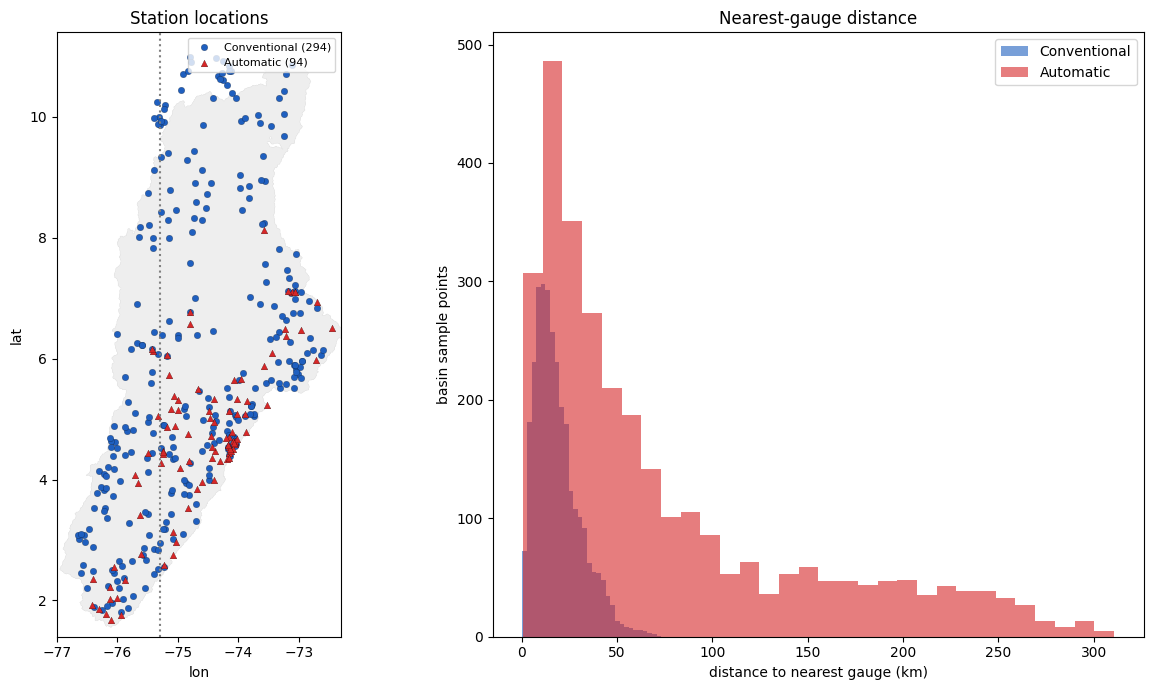

nearest-gauge distance (km)      automatic   conventional
  whole basin  median                46          16
  %% of basin >30 km from a gauge     63%%         17%%
  Cauca side   median                43          14
  Cauca side   %% >30 km              64%%         12%%


In [2]:
def km(a,o,c,d): return np.sqrt(((a-c)*111)**2+((o-d)*111*np.cos(np.radians((a+c)/2)))**2)
ys,xs=np.where(sub>0); s=np.random.RandomState(0).choice(len(ys),3000,replace=False)
plon=tr.c+(xs[s]+0.5)*tr.a; plat=tr.f+(ys[s]+0.5)*tr.e
def nearest(g): return np.min(km(plat[:,None],plon[:,None],g.lat.values[None,:],g.lon.values[None,:]),axis=1)
d_au=nearest(au); d_cv=nearest(cv); west=plon<-75.3

fig,ax=plt.subplots(1,2,figsize=(13,7))
ax[0].imshow(np.where(sub>0,1,np.nan),extent=ext,cmap='Greys',vmin=0,vmax=3,alpha=.3)
ax[0].scatter(cv.lon,cv.lat,c='#1f5fbf',s=22,label=f'Conventional ({cv.code.nunique()})',edgecolor='k',lw=.15)
ax[0].scatter(au.lon,au.lat,c='#d62728',marker='^',s=24,label=f'Automatic ({au.code.nunique()})',edgecolor='k',lw=.15)
ax[0].axvline(-75.3,ls=':',c='gray'); ax[0].set_title('Station locations'); ax[0].legend(loc='upper right',fontsize=8)
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat'); ax[0].set_xlim(ext[0],ext[1]); ax[0].set_ylim(ext[2],ext[3])
ax[1].hist(d_cv,bins=30,alpha=.6,color='#1f5fbf',label='Conventional'); ax[1].hist(d_au,bins=30,alpha=.6,color='#d62728',label='Automatic')
ax[1].set_xlabel('distance to nearest gauge (km)'); ax[1].set_ylabel('basin sample points'); ax[1].set_title('Nearest-gauge distance'); ax[1].legend()
plt.tight_layout(); plt.show()
print('nearest-gauge distance (km)      automatic   conventional')
print(f'  whole basin  median            {np.median(d_au):6.0f}      {np.median(d_cv):6.0f}')
print(f'  %% of basin >30 km from a gauge {100*np.mean(d_au>30):6.0f}%%     {100*np.mean(d_cv>30):6.0f}%%')
print(f'  Cauca side   median            {np.median(d_au[west]):6.0f}      {np.median(d_cv[west]):6.0f}')
print(f'  Cauca side   %% >30 km          {100*np.mean(d_au[west]>30):6.0f}%%     {100*np.mean(d_cv[west]>30):6.0f}%%')

## Test 2 — Do they agree where they overlap?

Where an automatic and a conventional gauge sit close together (<12 km) we can compare them directly. If
they matched, the choice would be cosmetic. They do **not**: we compare daily correlation and the ratio of
annual totals over 2015–16. A ratio < 1 means the automatic tipping-bucket **under-catches** (missed
tips during intense rain + dropped 10-min intervals) relative to the observer-read conventional gauge.

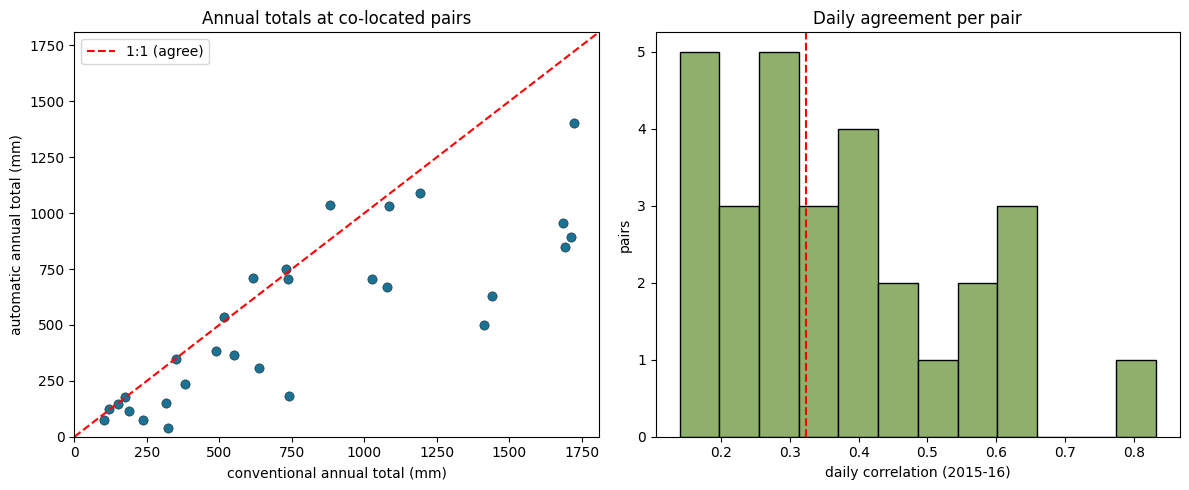

co-located pairs (<12 km): 29
  median daily correlation : 0.32   (1 = identical day-to-day)
  automatic/conventional annual-total ratio (median): 0.69   -> automatic under-catches ~31%%


In [3]:
xa=[];xd=[];cors=[]
for _,a in au.iterrows():
    dist=km(a.lat,a.lon,cv.lat,cv.lon); j=dist.idxmin()
    if dist.loc[j]<12:
        A=aud[aud.code==a.code]; D=cvd[cvd.code==cv.loc[j,'code']]
        m=A.merge(D,on='date'); m=m[(m.date.dt.year>=2015)&(m.date.dt.year<=2016)]
        if len(m)>60:
            xa.append(m.p_mm.sum()/2); xd.append(m.precip_mm.sum()/2); cors.append(m.p_mm.corr(m.precip_mm))
xa=np.array(xa); xd=np.array(xd)
fig,ax=plt.subplots(1,2,figsize=(12,5))
mx=max(xa.max(),xd.max())*1.05
ax[0].scatter(xd,xa,s=45,c='#1C7293',edgecolor='k',lw=.3); ax[0].plot([0,mx],[0,mx],'r--',label='1:1 (agree)')
ax[0].set_xlabel('conventional annual total (mm)'); ax[0].set_ylabel('automatic annual total (mm)')
ax[0].set_title('Annual totals at co-located pairs'); ax[0].legend(); ax[0].set_xlim(0,mx); ax[0].set_ylim(0,mx)
ax[1].hist(cors,bins=12,color='#8FB06B',edgecolor='k'); ax[1].axvline(np.median(cors),c='r',ls='--')
ax[1].set_xlabel('daily correlation (2015-16)'); ax[1].set_ylabel('pairs'); ax[1].set_title('Daily agreement per pair')
plt.tight_layout(); plt.show()
print(f'co-located pairs (<12 km): {len(xa)}')
print(f'  median daily correlation : {np.median(cors):.2f}   (1 = identical day-to-day)')
print(f'  automatic/conventional annual-total ratio (median): {np.median(xa/xd):.2f}   -> automatic under-catches ~{100*(1-np.median(xa/xd)):.0f}%%')

## Test 3 — Does each reproduce the ENSO signal?

The study rests on **2011 (La Niña, wet)** being clearly wetter than **2015–16 (El Niño, dry)**. A usable
network must reproduce that *known* contrast. For each network we take stations with data in both periods
and compare their mean daily rainfall. Both should land above the 1:1 line; the question is whether each
has *enough* stations to show it robustly.

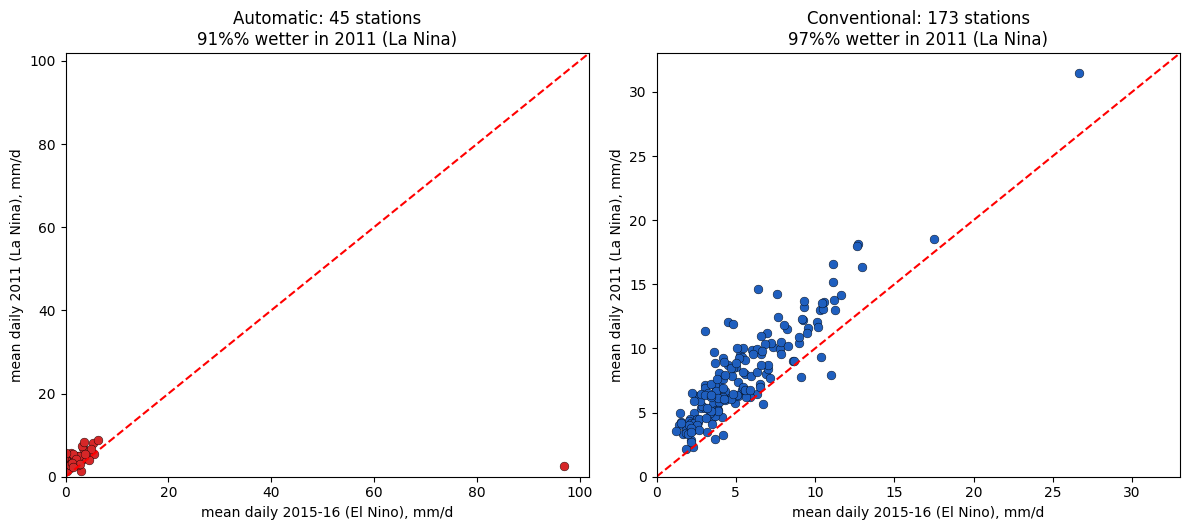

ENSO ratio 2011/(2015-16): automatic 1.85x (45 st) | conventional 1.53x (173 st)


In [4]:
def enso(daily,val):
    m11=daily[daily.date.dt.year==2011].groupby('code')[val].agg(m='mean',n='size')
    m56=daily[daily.date.dt.year.isin([2015,2016])].groupby('code')[val].agg(m='mean',n='size')
    p=m11.join(m56,lsuffix='11',rsuffix='56',how='inner'); p=p[(p.n11>=150)&(p.n56>=300)]
    return p
pa=enso(aud,'p_mm'); pc=enso(cvd,'precip_mm')
fig,ax=plt.subplots(1,2,figsize=(12,5.4))
for a,(p,ttl,col) in zip(ax,[(pa,'Automatic',' #d62728'),(pc,'Conventional','#1f5fbf')]):
    mx=max(p.m11.max(),p.m56.max())*1.05
    a.scatter(p.m56,p.m11,s=40,c=col.strip(),edgecolor='k',lw=.3); a.plot([0,mx],[0,mx],'r--')
    wet=100*(p.m11>p.m56).mean()
    a.set_title(f'{ttl}: {len(p)} stations\n{wet:.0f}%% wetter in 2011 (La Nina)')
    a.set_xlabel('mean daily 2015-16 (El Nino), mm/d'); a.set_ylabel('mean daily 2011 (La Nina), mm/d')
    a.set_xlim(0,mx); a.set_ylim(0,mx)
plt.tight_layout(); plt.show()
print(f'ENSO ratio 2011/(2015-16): automatic {pa.m11.median()/pa.m56.median():.2f}x ({len(pa)} st) | conventional {pc.m11.median()/pc.m56.median():.2f}x ({len(pc)} st)')

## Test 4 — Record length & validation status

Calibration runs 2008–2018 (validate out-of-sample on 2011 & 2015–16), so **record length matters**, and
so does whether the data is quality-controlled. Conventional carries an IDEAM approval flag; automatic is
raw. The bars show usable stations per study year and the conventional approval mix.

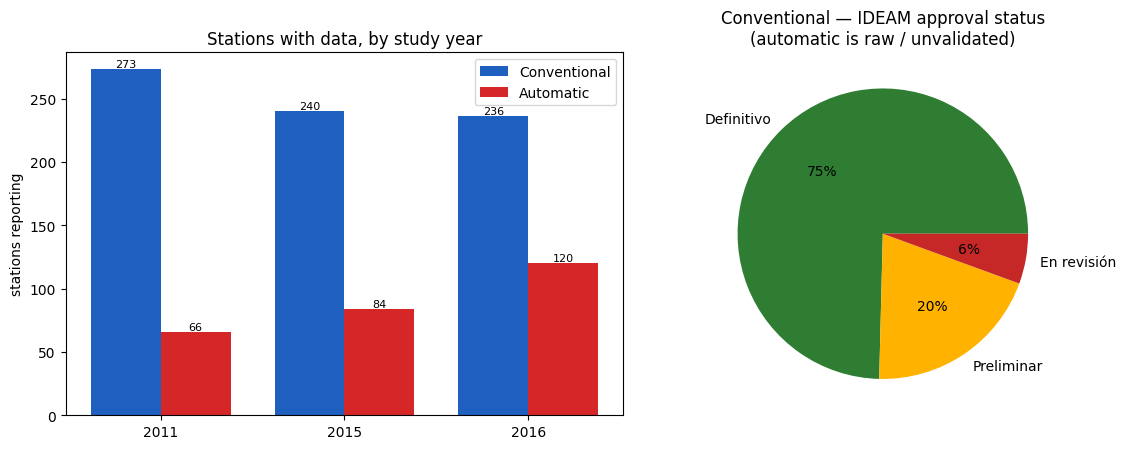

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
yrs=[2011,2015,2016]
cvc=[ (cvd.date.dt.year==y).groupby(cvd.code).any().sum() if False else cvd[cvd.date.dt.year==y].code.nunique() for y in yrs]
auc=[ aud[aud.date.dt.year==y].code.nunique() for y in yrs]
x=np.arange(3); w=.38
ax[0].bar(x-w/2,cvc,w,color='#1f5fbf',label='Conventional'); ax[0].bar(x+w/2,auc,w,color='#d62728',label='Automatic')
ax[0].set_xticks(x); ax[0].set_xticklabels(yrs); ax[0].set_ylabel('stations reporting'); ax[0].set_title('Stations with data, by study year'); ax[0].legend()
for i,(a,c) in enumerate(zip(auc,cvc)):
    ax[0].text(i-w/2,c,str(c),ha='center',va='bottom',fontsize=8); ax[0].text(i+w/2,a,str(a),ha='center',va='bottom',fontsize=8)
appr=cvd['approval'].value_counts()
ax[1].pie(appr.values,labels=appr.index,autopct='%1.0f%%',colors=['#2E7D32','#FFB300','#C62828'])
ax[1].set_title('Conventional — IDEAM approval status\n(automatic is raw / unvalidated)')
plt.tight_layout(); plt.show()

## Verdict — use the **conventional** network

| Test | Automatic | Conventional | Winner |
|---|---|---|---|
| **Coverage** | Magdalena-stem only; Cauca side largely >30 km from a gauge | whole basin, all 9 zones | **Conventional** |
| **Agreement** | under-catches ~30 %, noisy daily (r≈0.3) | the reference it under-catches *against* | **Conventional** |
| **ENSO signal** | present but few stations | present, many more stations | **Conventional** |
| **Record** | short, raw/unvalidated | 2008–2018, mostly *Definitivo* | **Conventional** |

**Decision.** The **conventional DHIME network (294 stations)** is the gauge truth for the CHIRPS
bias-correction. It covers the whole basin (the Cauca sediment region that automatic cannot see), it is
quality-controlled, it spans the full calibration period, and it does *not* carry the automatic network's
~30 % tipping-bucket under-catch. Mixing the two would inject that under-catch bias — so the automatic data
is **kept only as an independent cross-check**, never merged into the correction.

**Honest caveats.** The overlap correlation (~0.3) and under-catch ratio are inflated by the up-to-12 km
separation of "co-located" pairs (rain genuinely varies over 12 km in the Andes) — automatic is not "30 %
wrong" in an absolute sense. And even the conventional network thins in the high, remote headwaters, a
data-availability limit no product escapes; there CHIRPS + the gridded backbone carry the load.

**Next — the rainfall forcing (notebook 11).** Download CHIRPS daily for the basin, **quantile-map** it onto
these 294 conventional gauges to remove the tropical-Andes bias, and average the corrected field over each
minibacia to produce the daily rainfall that drives the MGB water balance.